## Telco Churn Predictor Dataset ~ By IBM

In [1]:

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [2]:
# Set random seeds for reproducibility
import os
np.random.seed(42)
import random
random.seed(42)
os.environ['PYTHONHASHSEED'] = '42'

### First Look into the Dataset

In [3]:
df = pd.read_csv("../dataset/telco_churn_data.csv")
df.shape

(7043, 21)

In [4]:
pd.set_option('display.max_columns', None)  # Show all columns in the DataFrame
pd.set_option('display.max_rows', None)     # Show all rows in the DataFrame

**Information**:
-> 7043 customer data and 21 features

In [5]:
df.tail(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,Yes,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.3,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [7]:
df['SeniorCitizen'].dtype

dtype('int64')

In [8]:
df['TotalCharges'].dtype

<StringDtype(storage='python', na_value=nan)>

**NOTE:** We need to change the datatype of TotalCharges

**Columns needing Binary Encoding:**  
gender  
SeniorCitizen  [already-done]  
Partner  
Dependents  
PhoneService  
PaperlessBilling  
Churn

**Columns needing One-Hot Encoding:**  
MultipleLines  
InternetService  
OnlineSecurity  
OnlineBackup  
DeviceProtection  
TechSupport  
StreamingTV  
StreamingMovies  
Contract  
PaymentMethod

### Encoding

**Binary Encoding**

In [9]:
binary_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
df[binary_columns] = df[binary_columns].replace({'Male':1, 'Female':0, 'Yes':1, 'No':0})
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


**One-Hot Encoding**

In [10]:
'''
MultipleLines  
InternetService  
OnlineSecurity  
OnlineBackup  
DeviceProtection  
TechSupport  
StreamingTV  
StreamingMovies  
Contract  
PaymentMethod
'''
multicat_columns = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multicat_columns, drop_first=True)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


### Data Cleaning

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [12]:
df = df.dropna(subset=['TotalCharges'])

In [13]:
df = df.drop(columns=['customerID'])

In [14]:
bool_columns = df.select_dtypes(include='bool').columns
df[bool_columns] = df[bool_columns].astype(int)

In [15]:
obj_columns = df.select_dtypes(include='object').columns
if len(obj_columns) > 0:
    print(f"Converting {len(obj_columns)} object columns to int:")
    for col in obj_columns:
        print(f"  {col}: {df[col].unique()}")
    df[obj_columns] = df[obj_columns].astype(int)
else:
    print("No object columns to convert.")

Converting 6 object columns to int:
  gender: [0 1]
  Partner: [1 0]
  Dependents: [0 1]
  PhoneService: [0 1]
  PaperlessBilling: [1 0]
  Churn: [0 1]


In [16]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [17]:
# We need to collapse redundant columns before running VIF
df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)

# Drop the original redundant dummies
drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns=drop_cols)

# Handle PhoneService redundancy
if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])

### Analysis

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_Yes                      7032 non-null   int64  
 11  InternetService_Fibe

In [19]:
corr = df.corr()

Correlation Analysis

In [20]:
churn_corr = corr[['Churn']].sort_values(by = 'Churn', ascending=False) # [['Churn']] -> turning the corr series into a dataframe

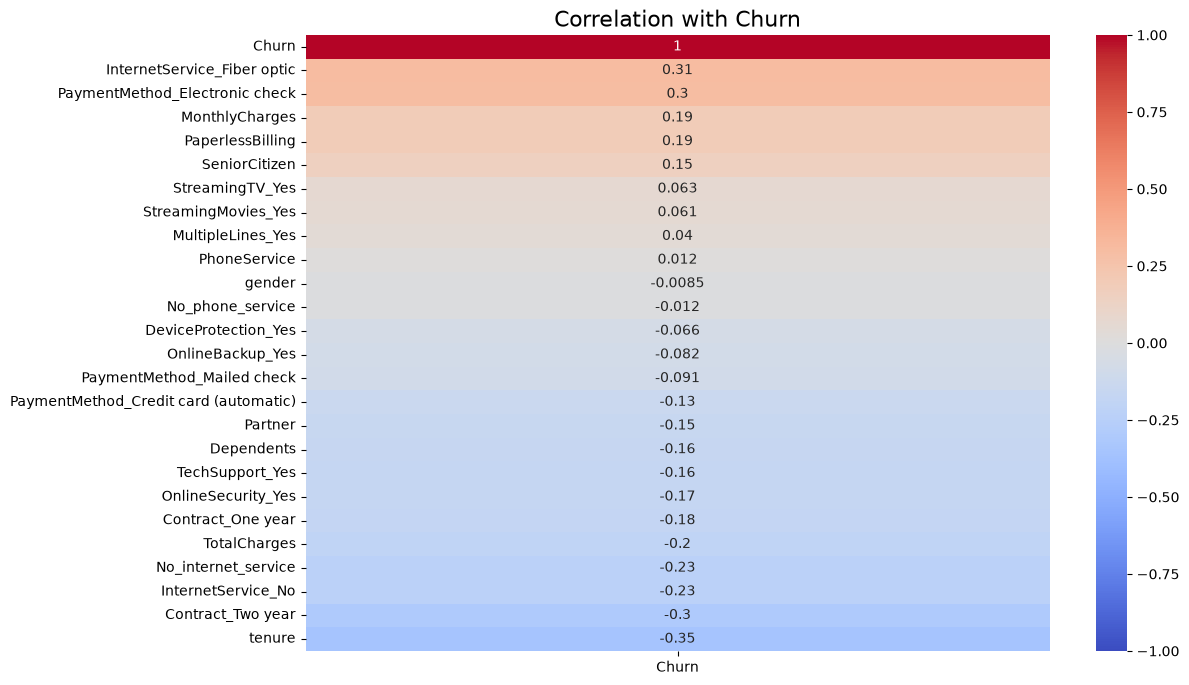

In [21]:
plt.figure(figsize=(12, 8))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', center=0, vmin= -1, vmax=1)
plt.title('Correlation with Churn', fontsize=16)
plt.show()

## Model Development

Let's look into the dataset if it has a class imbalance

In [22]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

We are dealing with class imbalance. There are multiple ways to deal with it.  
One way is to create a lower threshold for classification. Another is using resampling.  

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import time
import optuna


/home/dodo/projects/Telco Churn Predictor/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [25]:
# Test Train Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
# Since there is a class imbalance, we will use stratified sampling to ensure that the proportion of classes in the train and test sets is similar to that in the original dataset.
# Also we will use Threshold moving to adjust the decision threshold for better performance on the minority class.

THRESHOLD = 0.3 # We will chose lesser threshold to increase the recall of the minority class (class 1)

#### Random Forest Classifier

In [27]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [28]:
probabilities = rf.predict_proba(X_test)[:,1] # Get probabilities for the positive class

y_pred = (probabilities >= THRESHOLD).astype(int) # Apply threshold to get predicted classes

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.922     0.620     0.741      1033
           1      0.449     0.856     0.589       374

    accuracy                          0.682      1407
   macro avg      0.685     0.738     0.665      1407
weighted avg      0.796     0.682     0.701      1407



In [29]:
print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (probabilities >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Thresh  Prec_1  Rec_1   F1_1    
0.25    0.427   0.882   0.576   
0.3     0.449   0.856   0.589   
0.35    0.470   0.816   0.596   
0.4     0.495   0.754   0.597   
0.45    0.535   0.717   0.613   
0.5     0.558   0.671   0.609   


#### LightGBM Classifier

In [30]:
lgbm = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.03,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [31]:
start_time = time.time()

lgbm.fit(X_train, y_train)

train_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")


start_time = time.time()
probabilities = lgbm.predict_proba(X_test)[:,1]
pred_time = time.time() - start_time
y_pred = (probabilities>=THRESHOLD).astype(int)
print(f"Prediction time: {pred_time:.2f} seconds")
print(classification_report(y_test, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000724 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training time: 0.31 seconds
Prediction time: 0.00 seconds
              precision    recall  f1-score   support

           0       0.95      0.58      0.72      1033
           1       0.44      0.91      0.59       374

    accuracy                           0.67      1407
   macro avg       0.69      0.74      0.66      1407
weighted avg       0.81      0.67     

In [32]:
print("Threshold tuning for LightGBM")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (probabilities >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.416   0.922   0.574   
0.3     0.440   0.906   0.593   
0.35    0.458   0.858   0.597   
0.4     0.471   0.837   0.603   
0.45    0.493   0.816   0.614   
0.5     0.505   0.791   0.617   


In [33]:
# def objective_recall(trial):
#     params = {
#         "boosting_type": trial.suggest_categorical("boosting_type", ['gbdt', 'dart','rf']),
#         "num_leaves": trial.suggest_int("num_leaves", 20, 50),
#         "n_estimators": trial.suggest_int("n_estimators", 200, 800),
#         "objective": 'binary',
#         "class_weight": 'balanced',
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
#         "max_depth": -1,
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1e-3, 1),
#         "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
#         "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
#         "random_state": 42,
#         "n_jobs": -1
#     }
    
#     model = LGBMClassifier(**params)
#     model.fit(X_train, y_train)
#     proba = model.predict_proba(X_test)[:, 1]
#     y_pred = (proba >= THRESHOLD).astype(int)  # Keep your tuned threshold
#     return recall_score(y_test, y_pred, pos_label=1)  #Optimize recall for churners

In [34]:
# study_recall = optuna.create_study(direction="maximize")
# study_recall.optimize(objective_recall, n_trials=100)

# print("Best Params:", study_recall.best_params)
# print("Best Recall:", study_recall.best_value)

In [35]:
# best_recall_params = study_recall.best_params
# params = {**best_recall_params, "objective": 'binary', "class_weight": 'balanced', "max_depth": -1, "random_state": 42, "n_jobs": -1}
# lgbm_recall = LGBMClassifier(**params)

# start_time = time.time()

# lgbm_recall.fit(X_train, y_train)

# train_time = time.time() - start_time

# print(f"Training time: {train_time:.2f} seconds")


# start_time = time.time()
# probabilities = lgbm_recall.predict_proba(X_test)[:,1]
# pred_time = time.time() - start_time
# y_pred = (probabilities>=THRESHOLD).astype(int)
# print(f"Prediction time: {pred_time:.2f} seconds")
# print(classification_report(y_test, y_pred))

This is not a viable model because it achieves a 100% recall by predicting every datapoint as churn

#### XGBoost Classifier

In [36]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42, 
    n_jobs=1,
    scale_pos_weight= (y_train == 0).sum()/(y_train == 1).sum(),
    eval_metric='logloss'
)

In [37]:
start_time = time.time()

xgb.fit(X_train, y_train)

train_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")


start_time = time.time()
probabilities = xgb.predict_proba(X_test)[:,1]
pred_time = time.time() - start_time
y_pred = (probabilities>=THRESHOLD).astype(int)
print(f"Prediction time: {pred_time:.2f} seconds")
print(classification_report(y_test, y_pred))

Training time: 0.28 seconds
Prediction time: 0.01 seconds
              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1033
           1       0.47      0.81      0.59       374

    accuracy                           0.71      1407
   macro avg       0.69      0.74      0.68      1407
weighted avg       0.79      0.71      0.72      1407



In [38]:
def objective_xgb_recall(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": 1,
        "scale_pos_weight": (y_train == 0).sum()/(y_train == 1).sum(),
        "eval_metric": 'logloss'
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    return recall_score(y_test, y_pred, pos_label=1)

In [39]:
sampler = optuna.samplers.TPESampler(seed=42)
study_xgb_recall = optuna.create_study(sampler=sampler, direction="maximize")
study_xgb_recall.optimize(objective_xgb_recall, n_trials=100, show_progress_bar=True)

print("Best Params:", study_xgb_recall.best_params)
print("Best Recall:", study_xgb_recall.best_value)

[I 2026-09-12 09:29:56,083] A new study created in memory with name: no-name-e96cc9ef-cbbe-40c6-86a1-78e52541cc3c
Best trial: 0. Best value: 0.641711:   1%|          | 1/100 [00:00<00:44,  2.22it/s]

[I 2026-09-12 09:29:56,532] Trial 0 finished with value: 0.6417112299465241 and parameters: {'n_estimators': 612, 'learning_rate': 0.19063571821788408, 'max_depth': 8, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'reg_alpha': 0.7799726016810132, 'reg_lambda': 0.2904180608409973}. Best is trial 0 with value: 0.6417112299465241.


Best trial: 1. Best value: 0.745989:   2%|▏         | 2/100 [00:01<00:53,  1.84it/s]

[I 2026-09-12 09:29:57,141] Trial 1 finished with value: 0.7459893048128342 and parameters: {'n_estimators': 760, 'learning_rate': 0.12421185223120967, 'max_depth': 8, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'reg_alpha': 4.162213204002109, 'reg_lambda': 1.0616955533913808}. Best is trial 1 with value: 0.7459893048128342.


Best trial: 2. Best value: 0.850267:   3%|▎         | 3/100 [00:01<00:40,  2.42it/s]

...

[I 2026-09-12 09:30:22,000] Trial 96 finished with value: 0.9010695187165776 and parameters: {'n_estimators': 615, 'learning_rate': 0.017671012616000837, 'max_depth': 4, 'subsample': 0.6098001736420102, 'colsample_bytree': 0.5941512152285761, 'reg_alpha': 4.601974467882782, 'reg_lambda': 1.1339648870797867}. Best is trial 21 with value: 0.9197860962566845.
[I 2026-09-12 09:30:22,169] Trial 97 finished with value: 0.8983957219251337 and parameters: {'n_estimators': 592, 'learning_rate': 0.0238184515805134, 'max_depth': 3, 'subsample': 0.9984325435524661, 'colsample_bytree': 0.5457120596850893, 'reg_alpha': 4.994671907748748, 'reg_lambda': 1.8023530695369918}. Best is trial 21 with value: 0.9197860962566845.


Best trial: 21. Best value: 0.919786:  99%|█████████▉| 99/100 [00:26<00:00,  4.46it/s]

[I 2026-09-12 09:30:22,439] Trial 98 finished with value: 0.893048128342246 and parameters: {'n_estimators': 640, 'learning_rate': 0.027734592369392005, 'max_depth': 4, 'subsample': 0.5626427852134397, 'colsample_bytree': 0.636184998377636, 'reg_alpha': 4.439134710616343, 'reg_lambda': 1.9811362250635771}. Best is trial 21 with value: 0.9197860962566845.


Best trial: 21. Best value: 0.919786: 100%|██████████| 100/100 [00:26<00:00,  3.77it/s]

[I 2026-09-12 09:30:22,642] Trial 99 finished with value: 0.9144385026737968 and parameters: {'n_estimators': 623, 'learning_rate': 0.013999806487161232, 'max_depth': 3, 'subsample': 0.6639637333024273, 'colsample_bytree': 0.5094256563039512, 'reg_alpha': 4.787870681351194, 'reg_lambda': 2.429037014539197}. Best is trial 21 with value: 0.9197860962566845.
Best Params: {'n_estimators': 649, 'learning_rate': 0.01053859126067838, 'max_depth': 3, 'subsample': 0.6317696186148078, 'colsample_bytree': 0.5983337364181645, 'reg_alpha': 4.966825580763828, 'reg_lambda': 1.8816195321596936}
Best Recall: 0.9197860962566845


In [40]:
best_xgb_params = study_xgb_recall.best_params
params = {**best_xgb_params, "random_state": 42, "n_jobs": 1, "scale_pos_weight": (y_train == 0).sum()/(y_train == 1).sum(), "eval_metric": 'logloss'}
xgb_recall = XGBClassifier(**params)

start_time = time.time()

xgb_recall.fit(X_train, y_train)

train_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")


start_time = time.time()
probabilities = xgb_recall.predict_proba(X_test)[:,1]
pred_time = time.time() - start_time
y_pred = (probabilities>=THRESHOLD).astype(int)
print(f"Prediction time: {pred_time:.2f} seconds")
print(classification_report(y_test, y_pred))

Training time: 0.21 seconds
Prediction time: 0.01 seconds
              precision    recall  f1-score   support

           0       0.95      0.55      0.70      1033
           1       0.43      0.92      0.58       374

    accuracy                           0.65      1407
   macro avg       0.69      0.74      0.64      1407
weighted avg       0.81      0.65      0.67      1407



In [41]:
print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (probabilities >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.410   0.936   0.570   
0.3     0.428   0.920   0.584   
0.35    0.442   0.890   0.591   
0.4     0.456   0.869   0.598   
0.45    0.472   0.837   0.604   
0.5     0.501   0.813   0.620   


In [42]:
from sklearn.metrics import average_precision_score


def objective_xgb_AP(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 400, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": 1,
        "scale_pos_weight": (y_train == 0).sum()/(y_train == 1).sum(),
        "eval_metric": 'logloss'
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    return average_precision_score(y_test, y_pred, pos_label=1)

In [43]:
sampler = optuna.samplers.TPESampler(seed=42)
study_xgb_AP = optuna.create_study(sampler=sampler, direction="maximize")
study_xgb_AP.optimize(objective_xgb_AP, n_trials=100, show_progress_bar=True)

print("Best Params:", study_xgb_AP.best_params)
print("Best AP:", study_xgb_AP.best_value)

[I 2026-09-12 09:30:22,906] A new study created in memory with name: no-name-c3675272-d433-4d17-ae96-77da125555fb
Best trial: 0. Best value: 0.422225:   1%|          | 1/100 [00:00<00:39,  2.50it/s]

[I 2026-09-12 09:30:23,306] Trial 0 finished with value: 0.4222247092235852 and parameters: {'n_estimators': 550, 'learning_rate': 0.19063571821788408, 'max_depth': 8, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'reg_alpha': 0.7799726016810132, 'reg_lambda': 0.2904180608409973}. Best is trial 0 with value: 0.4222247092235852.


Best trial: 1. Best value: 0.426359:   2%|▏         | 2/100 [00:00<00:50,  1.95it/s]

[I 2026-09-12 09:30:23,898] Trial 1 finished with value: 0.4263586991536198 and parameters: {'n_estimators': 747, 'learning_rate': 0.12421185223120967, 'max_depth': 8, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'reg_alpha': 4.162213204002109, 'reg_lambda': 1.0616955533913808}. Best is trial 1 with value: 0.4263586991536198.


Best trial: 2. Best value: 0.430192:   3%|▎         | 3/100 [00:01<00:36,  2.63it/s]

...

[I 2026-09-12 09:31:13,388] Trial 97 finished with value: 0.42831697223248527 and parameters: {'n_estimators': 694, 'learning_rate': 0.11094851285035338, 'max_depth': 10, 'subsample': 0.985799331634412, 'colsample_bytree': 0.7929237049859554, 'reg_alpha': 4.27218582521798, 'reg_lambda': 0.38343723040995065}. Best is trial 92 with value: 0.4427081902488623.


Best trial: 92. Best value: 0.442708:  99%|█████████▉| 99/100 [00:51<00:00,  1.79it/s]

[I 2026-09-12 09:31:13,969] Trial 98 finished with value: 0.44014059762303837 and parameters: {'n_estimators': 668, 'learning_rate': 0.07976836136973645, 'max_depth': 10, 'subsample': 0.9246136294306011, 'colsample_bytree': 0.7714077315466007, 'reg_alpha': 4.412929266567175, 'reg_lambda': 0.6547220292306927}. Best is trial 92 with value: 0.4427081902488623.


Best trial: 92. Best value: 0.442708: 100%|██████████| 100/100 [00:51<00:00,  1.95it/s]

[I 2026-09-12 09:31:14,260] Trial 99 finished with value: 0.43425247401931133 and parameters: {'n_estimators': 626, 'learning_rate': 0.10518906306183644, 'max_depth': 5, 'subsample': 0.9312728659380731, 'colsample_bytree': 0.7528878113356278, 'reg_alpha': 4.49136481560347, 'reg_lambda': 0.867870274407244}. Best is trial 92 with value: 0.4427081902488623.
Best Params: {'n_estimators': 685, 'learning_rate': 0.09394523706902029, 'max_depth': 10, 'subsample': 0.9790763527450661, 'colsample_bytree': 0.8129325172752467, 'reg_alpha': 3.9939391388895302, 'reg_lambda': 0.4350450106025643}
Best AP: 0.4427081902488623


In [44]:
best_xgb_params = study_xgb_AP.best_params
params = {**best_xgb_params, "random_state": 42, "n_jobs": 1, "scale_pos_weight": (y_train == 0).sum()/(y_train == 1).sum(), "eval_metric": 'logloss'}
xgb_recall = XGBClassifier(**params)

start_time = time.time()

xgb_recall.fit(X_train, y_train)

train_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")


start_time = time.time()
probabilities = xgb_recall.predict_proba(X_test)[:,1]
pred_time = time.time() - start_time
y_pred = (probabilities>=THRESHOLD).astype(int)
print(f"Prediction time: {pred_time:.2f} seconds")
print(classification_report(y_test, y_pred))

Training time: 0.55 seconds
Prediction time: 0.02 seconds
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [45]:
print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (probabilities >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.473   0.802   0.595   
0.3     0.492   0.783   0.604   
0.35    0.501   0.741   0.598   
0.4     0.517   0.701   0.595   
0.45    0.528   0.676   0.593   
0.5     0.541   0.647   0.590   


In [46]:
from sklearn.metrics import roc_auc_score


def objective_xgb_ROCAUC(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 400, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": 1,
        "scale_pos_weight": (y_train == 0).sum()/(y_train == 1).sum(),
        "eval_metric": 'logloss'
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    return roc_auc_score(y_test, y_pred)

In [47]:
sampler = optuna.samplers.TPESampler(seed=42)
study_xgb_ROCAUC = optuna.create_study(sampler=sampler, direction="maximize")
study_xgb_ROCAUC.optimize(objective_xgb_ROCAUC, n_trials=100, show_progress_bar=True)

print("Best Params:", study_xgb_ROCAUC.best_params)
print("Best ROC-AUC Score:", study_xgb_ROCAUC.best_value)

[I 2026-09-12 09:31:14,873] A new study created in memory with name: no-name-b8026c55-21b6-4e32-ab20-09550d48858b
Best trial: 0. Best value: 0.709045:   1%|          | 1/100 [00:00<00:39,  2.48it/s]

[I 2026-09-12 09:31:15,275] Trial 0 finished with value: 0.709045353598625 and parameters: {'n_estimators': 550, 'learning_rate': 0.19063571821788408, 'max_depth': 8, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'reg_alpha': 0.7799726016810132, 'reg_lambda': 0.2904180608409973}. Best is trial 0 with value: 0.709045353598625.


Best trial: 1. Best value: 0.726565:   2%|▏         | 2/100 [00:00<00:50,  1.93it/s]

[I 2026-09-12 09:31:15,872] Trial 1 finished with value: 0.7265648052761543 and parameters: {'n_estimators': 747, 'learning_rate': 0.12421185223120967, 'max_depth': 8, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'reg_alpha': 4.162213204002109, 'reg_lambda': 1.0616955533913808}. Best is trial 1 with value: 0.7265648052761543.


Best trial: 2. Best value: 0.745099:   3%|▎         | 3/100 [00:01<00:37,  2.58it/s]

...

[I 2026-09-12 09:31:57,363] Trial 97 finished with value: 0.7435536390037842 and parameters: {'n_estimators': 401, 'learning_rate': 0.03909698394447666, 'max_depth': 8, 'subsample': 0.8681068576395824, 'colsample_bytree': 0.591402830490456, 'reg_alpha': 0.21255168520511591, 'reg_lambda': 3.010179830763137}. Best is trial 93 with value: 0.7511828897712389.


Best trial: 93. Best value: 0.751183:  99%|█████████▉| 99/100 [00:42<00:00,  2.68it/s]

[I 2026-09-12 09:31:57,770] Trial 98 finished with value: 0.7255035693763556 and parameters: {'n_estimators': 439, 'learning_rate': 0.13064959582663216, 'max_depth': 9, 'subsample': 0.8134133497634917, 'colsample_bytree': 0.6195046262838283, 'reg_alpha': 0.432909047741427, 'reg_lambda': 2.885394811985398}. Best is trial 93 with value: 0.7511828897712389.


Best trial: 93. Best value: 0.751183: 100%|██████████| 100/100 [00:43<00:00,  2.31it/s]

[I 2026-09-12 09:31:58,089] Trial 99 finished with value: 0.7407646592915085 and parameters: {'n_estimators': 420, 'learning_rate': 0.04385062249984731, 'max_depth': 8, 'subsample': 0.9198961477298704, 'colsample_bytree': 0.5429676156150162, 'reg_alpha': 0.5734420238214069, 'reg_lambda': 3.1330627812576384}. Best is trial 93 with value: 0.7511828897712389.
Best Params: {'n_estimators': 425, 'learning_rate': 0.038947127208436357, 'max_depth': 8, 'subsample': 0.5138661470754012, 'colsample_bytree': 0.6396534808361383, 'reg_alpha': 0.6693516423110188, 'reg_lambda': 2.963464383894832}
Best ROC-AUC Score: 0.7511828897712389


In [48]:
best_xgb_params = study_xgb_ROCAUC.best_params
params = {**best_xgb_params, "random_state": 42, "n_jobs": 1, "scale_pos_weight": (y_train == 0).sum()/(y_train == 1).sum(), "eval_metric": 'logloss'}
xgb_recall = XGBClassifier(**params)

start_time = time.time()

xgb_recall.fit(X_train, y_train)

train_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")


start_time = time.time()
probabilities = xgb_recall.predict_proba(X_test)[:,1]
pred_time = time.time() - start_time
y_pred = (probabilities>=THRESHOLD).astype(int)
print(f"Prediction time: {pred_time:.2f} seconds")
print(classification_report(y_test, y_pred))

Training time: 0.34 seconds
Prediction time: 0.01 seconds
              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1033
           1       0.48      0.82      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.69      1407
weighted avg       0.80      0.72      0.73      1407



In [52]:
from sklearn.model_selection import cross_val_score

def objective_xgb_ROCAUC_CrossVal(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 400, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": 1,
        "scale_pos_weight": (y_train == 0).sum()/(y_train == 1).sum(),
        "eval_metric": 'logloss'
    }
    
    model = XGBClassifier(**params)

    scores = cross_val_score(
        model, X, y,
        cv=5,
        scoring="roc_auc"
    )
    
    return scores.mean()

In [53]:
sampler = optuna.samplers.TPESampler(seed=42)
study_xgb_ROCAUC_CV = optuna.create_study(sampler=sampler, direction="maximize")
study_xgb_ROCAUC_CV.optimize(objective_xgb_ROCAUC_CrossVal, n_trials=100, show_progress_bar=True)

print("Best Params:", study_xgb_ROCAUC_CV.best_params)
print("Best ROC-AUC Score:", study_xgb_ROCAUC_CV.best_value)

[I 2026-09-12 09:34:14,472] A new study created in memory with name: no-name-8b372cf7-0c99-4975-b636-bffe3d1c65d7
Best trial: 0. Best value: 0.799963:   1%|          | 1/100 [00:02<03:21,  2.03s/it]

[I 2026-09-12 09:34:16,506] Trial 0 finished with value: 0.799963148898515 and parameters: {'n_estimators': 550, 'learning_rate': 0.19063571821788408, 'max_depth': 8, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'reg_alpha': 0.7799726016810132, 'reg_lambda': 0.2904180608409973}. Best is trial 0 with value: 0.799963148898515.


Best trial: 1. Best value: 0.808937:   2%|▏         | 2/100 [00:05<04:14,  2.60s/it]

[I 2026-09-12 09:34:19,505] Trial 1 finished with value: 0.8089372991567055 and parameters: {'n_estimators': 747, 'learning_rate': 0.12421185223120967, 'max_depth': 8, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'reg_alpha': 4.162213204002109, 'reg_lambda': 1.0616955533913808}. Best is trial 1 with value: 0.8089372991567055.


Best trial: 2. Best value: 0.836946:   3%|▎         | 3/100 [00:06<03:06,  1.92s/it]

...

[I 2026-09-12 09:36:18,811] Trial 97 finished with value: 0.8489606155134307 and parameters: {'n_estimators': 645, 'learning_rate': 0.01948635979441266, 'max_depth': 3, 'subsample': 0.6145185735332698, 'colsample_bytree': 0.9389330971306369, 'reg_alpha': 4.346350518497306, 'reg_lambda': 4.170456910962961}. Best is trial 22 with value: 0.8501424161303639.


Best trial: 22. Best value: 0.850142:  99%|█████████▉| 99/100 [02:05<00:01,  1.26s/it]

[I 2026-09-12 09:36:19,828] Trial 98 finished with value: 0.8487911650547055 and parameters: {'n_estimators': 608, 'learning_rate': 0.026309058718258595, 'max_depth': 3, 'subsample': 0.5964768642816831, 'colsample_bytree': 0.5946000974125911, 'reg_alpha': 3.4878663593448573, 'reg_lambda': 4.57844631243613}. Best is trial 22 with value: 0.8501424161303639.


Best trial: 22. Best value: 0.850142: 100%|██████████| 100/100 [02:06<00:00,  1.27s/it]

[I 2026-09-12 09:36:21,188] Trial 99 finished with value: 0.8472638831242152 and parameters: {'n_estimators': 698, 'learning_rate': 0.020075728875622093, 'max_depth': 4, 'subsample': 0.6639637333024273, 'colsample_bytree': 0.5426379396997999, 'reg_alpha': 4.130263327254179, 'reg_lambda': 4.013217649158469}. Best is trial 22 with value: 0.8501424161303639.
Best Params: {'n_estimators': 671, 'learning_rate': 0.01242909533604329, 'max_depth': 3, 'subsample': 0.6553463721605057, 'colsample_bytree': 0.5552519162247597, 'reg_alpha': 4.068461876423589, 'reg_lambda': 4.163453884083982}
Best ROC-AUC Score: 0.8501424161303639


In [54]:
best_xgb_params = study_xgb_ROCAUC_CV.best_params
params = {**best_xgb_params, "random_state": 42, "n_jobs": 1, "scale_pos_weight": (y_train == 0).sum()/(y_train == 1).sum(), "eval_metric": 'logloss'}
xgb_recall = XGBClassifier(**params)

start_time = time.time()

xgb_recall.fit(X_train, y_train)

train_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")


start_time = time.time()
probabilities = xgb_recall.predict_proba(X_test)[:,1]
pred_time = time.time() - start_time
y_pred = (probabilities>=THRESHOLD).astype(int)
print(f"Prediction time: {pred_time:.2f} seconds")
print(classification_report(y_test, y_pred))

Training time: 0.21 seconds
Prediction time: 0.01 seconds
              precision    recall  f1-score   support

           0       0.95      0.56      0.71      1033
           1       0.43      0.92      0.59       374

    accuracy                           0.66      1407
   macro avg       0.69      0.74      0.65      1407
weighted avg       0.81      0.66      0.67      1407

